## Cell 1 — Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Fix seed so every team member gets the same split
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Libraries ready.')

Libraries ready.


In [3]:
# Load raw data
df_raw = pd.read_csv("insurance.csv")

print(f'Shape : {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
print(f'\nColumns and types:')
print(df_raw.dtypes)
print(f'\nFirst 5 rows:')
display(df_raw.head())

Shape : 1338 rows x 7 columns

Columns and types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print('=== 1. MISSING VALUES ===')
print(df_raw.isnull().sum())
print('\nTotal missing:', df_raw.isnull().sum().sum())

print('\n=== 2. DUPLICATE ROWS ===')
print('Duplicates:', df_raw.duplicated().sum())

print('\n=== 3. UNIQUE VALUES (categorical) ===')
for col in ['sex', 'smoker', 'region']:
    print(f'  {col}: {df_raw[col].unique()}')

print('\n=== 4. NUMERIC RANGES ===')
for col in ['age', 'bmi', 'children', 'charges']:
    Q1  = df_raw[col].quantile(0.25)
    Q3  = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    ub  = Q3 + 1.5 * IQR
    out = (df_raw[col] > ub).sum()
    print(f'  {col}: min={df_raw[col].min():.1f}, max={df_raw[col].max():.1f}, IQR_upper={ub:.1f}, outliers_above={out}')

=== 1. MISSING VALUES ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing: 0

=== 2. DUPLICATE ROWS ===
Duplicates: 1

=== 3. UNIQUE VALUES (categorical) ===
  sex: ['female' 'male']
  smoker: ['yes' 'no']
  region: ['southwest' 'southeast' 'northwest' 'northeast']

=== 4. NUMERIC RANGES ===
  age: min=18.0, max=64.0, IQR_upper=87.0, outliers_above=0
  bmi: min=16.0, max=53.1, IQR_upper=47.3, outliers_above=9
  children: min=0.0, max=5.0, IQR_upper=5.0, outliers_above=0
  charges: min=1121.9, max=63770.4, IQR_upper=34489.4, outliers_above=139


In [5]:
# Manual split using NumPy — no sklearn!
n = len(df_raw)
indices = np.arange(n)
np.random.shuffle(indices)         # shuffle with fixed seed=42

split_point = int(n * 0.80)        # 80% train, 20% test
train_idx = indices[:split_point]
test_idx  = indices[split_point:]

df_train = df_raw.iloc[train_idx].reset_index(drop=True)
df_test  = df_raw.iloc[test_idx].reset_index(drop=True)

print(f'Total : {n}')
print(f'Train : {len(df_train)} rows ({len(df_train)/n*100:.0f}%)')
print(f'Test  : {len(df_test)}  rows ({len(df_test)/n*100:.0f}%)')

# Sanity check — no overlap
assert len(set(train_idx) & set(test_idx)) == 0
print('No overlap between train and test.')

Total : 1338
Train : 1070 rows (80%)
Test  : 268  rows (20%)
No overlap between train and test.


In [6]:
# Check if charges is skewed — important for linear regression assumption
charges = df_train['charges']

print('=== charges statistics (Train) ===')
print(f'Mean   : {charges.mean():,.2f}')
print(f'Median : {charges.median():,.2f}')
print(f'Std    : {charges.std():,.2f}')
print(f'Skew   : {charges.skew():.2f}  ← should be close to 0 for normal distribution')

# Plot distribution
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['charges distribution', 'log(charges) distribution'])

fig.add_trace(go.Histogram(x=charges, nbinsx=40,
              name='charges', marker_color='steelblue'), row=1, col=1)

fig.add_trace(go.Histogram(x=np.log(charges), nbinsx=40,
              name='log(charges)', marker_color='teal'), row=1, col=2)

fig.update_layout(title='Target Variable Distribution (Train Set)',
                  showlegend=False, height=400)
fig.show()

print('\nNote: charges is right-skewed — the log transformation looks more normal.')
print('The modeling team can decide whether to use log(charges) as the target.')

=== charges statistics (Train) ===
Mean   : 13,314.71
Median : 9,440.09
Std    : 12,011.35
Skew   : 1.48  ← should be close to 0 for normal distribution



Note: charges is right-skewed — the log transformation looks more normal.
The modeling team can decide whether to use log(charges) as the target.


In [7]:
# Smoker is the dominant feature — prove it visually
smoker_mean    = df_train[df_train['smoker'] == 'yes']['charges'].mean()
nonsmoker_mean = df_train[df_train['smoker'] == 'no']['charges'].mean()

print(f'Smoker mean charges    : ${smoker_mean:,.0f}')
print(f'Non-smoker mean charges: ${nonsmoker_mean:,.0f}')
print(f'Ratio                  : {smoker_mean/nonsmoker_mean:.1f}x more expensive')

# Box plot: charges by smoker
fig = px.box(df_train, x='smoker', y='charges', color='smoker',
             title='Charges: Smokers vs Non-Smokers (Train Set)',
             color_discrete_map={'yes': '#E24B4A', 'no': '#1D9E75'})
fig.show()

Smoker mean charges    : $31,747
Non-smoker mean charges: $8,489
Ratio                  : 3.7x more expensive


In [8]:
# Compute correlation on RAW data — before encoding and scaling
# This gives the true picture of relationships
df_corr = df_train.copy()
df_corr['sex']    = df_corr['sex'].map({'male': 1, 'female': 0})
df_corr['smoker'] = df_corr['smoker'].map({'yes': 1, 'no': 0})
# For region: just drop it from correlation (will be one-hot encoded later)
df_corr = df_corr.drop(columns=['region'])

corr_matrix = df_corr.corr(numeric_only=True)

# Full heatmap
fig = px.imshow(corr_matrix, text_auto='.2f',
                color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
                title='Correlation Heatmap — Train Set (raw values)')
fig.update_layout(width=650, height=550)
fig.show()

# Correlation with target specifically
print('\nCorrelation with charges (absolute, sorted):')
target_corr = corr_matrix['charges'].drop('charges').abs().sort_values(ascending=False)
print(target_corr)
print(f'\nBest single predictor: {target_corr.idxmax()} ({target_corr.max():.3f})')


Correlation with charges (absolute, sorted):
smoker      0.785552
age         0.296984
bmi         0.195103
sex         0.068993
children    0.060071
Name: charges, dtype: float64

Best single predictor: smoker (0.786)


In [9]:
# Visualize spread and outliers for all numeric features
numeric_cols = ['age', 'bmi', 'children', 'charges']

fig = make_subplots(rows=1, cols=4, subplot_titles=numeric_cols)

for i, col in enumerate(numeric_cols, 1):
    fig.add_trace(
        go.Box(y=df_train[col], name=col, showlegend=False,
               marker_color='steelblue'),
        row=1, col=i
    )

fig.update_layout(title='Box Plots — Numeric Features (Train Set)', height=420)
fig.show()

# BMI outliers detail
Q1  = df_train['bmi'].quantile(0.25)
Q3  = df_train['bmi'].quantile(0.75)
IQR = Q3 - Q1
bmi_upper = Q3 + 1.5 * IQR
print(f'BMI IQR upper bound : {bmi_upper:.2f}')
print(f'BMI outliers (train): {(df_train["bmi"] > bmi_upper).sum()} rows')
print('\nNote: charges outliers are real (smokers) — NOT data entry errors. Keep them.')

BMI IQR upper bound : 47.53
BMI outliers (train): 6 rows

Note: charges outliers are real (smokers) — NOT data entry errors. Keep them.


In [10]:
# Mean charges per category — does the category affect cost?
cat_cols = ['sex', 'smoker', 'region']

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=[f'charges by {c}' for c in cat_cols])

for i, col in enumerate(cat_cols, 1):
    grp = df_train.groupby(col)['charges'].mean().reset_index()
    fig.add_trace(
        go.Bar(x=grp[col], y=grp['charges'].round(0),
               name=col, showlegend=False,
               text=grp['charges'].round(0), textposition='outside'),
        row=1, col=i
    )

fig.update_layout(title='Mean Charges by Categorical Features (Train Set)', height=420)
fig.show()

In [11]:
# Scatter plots colored by smoker — reveals the main pattern
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['age vs charges', 'bmi vs charges'])

for smoker_val, color in [('yes', '#E24B4A'), ('no', '#1D9E75')]:
    mask = df_train['smoker'] == smoker_val
    fig.add_trace(
        go.Scatter(x=df_train.loc[mask, 'age'],
                   y=df_train.loc[mask, 'charges'],
                   mode='markers', name=f'smoker={smoker_val}',
                   marker=dict(color=color, size=4, opacity=0.6)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=df_train.loc[mask, 'bmi'],
                   y=df_train.loc[mask, 'charges'],
                   mode='markers', name=f'smoker={smoker_val}',
                   marker=dict(color=color, size=4, opacity=0.6),
                   showlegend=False),
        row=1, col=2
    )

fig.update_layout(title='Age & BMI vs Charges — colored by Smoker (Train Set)',
                  height=420)
fig.show()

---
## PREPROCESSING

## Cell 11 — Remove Duplicate Row

In [12]:
# Remove the 1 duplicate row found during diagnosis
# Only apply to train — test is independent
before = len(df_train)
train  = df_train.drop_duplicates().reset_index(drop=True)
test   = df_test.drop_duplicates().reset_index(drop=True)

print(f'Train: {before} → {len(train)} rows (removed {before - len(train)} duplicate)')
print(f'Test : {len(df_test)} → {len(test)} rows')

Train: 1070 → 1069 rows (removed 1 duplicate)
Test : 268 → 268 rows


In [13]:
# Cap BMI at 47.3 (IQR upper bound = Q3 + 1.5*IQR)
# This is a domain rule — BMI above 47 is extremely rare and likely a data entry error
# We use clip (not drop) to keep all rows
# IMPORTANT: compute the cap from TRAIN only, apply to both

Q3_bmi  = train['bmi'].quantile(0.75)
IQR_bmi = Q3_bmi - train['bmi'].quantile(0.25)
BMI_CAP = Q3_bmi + 1.5 * IQR_bmi

print(f'BMI cap (from train): {BMI_CAP:.2f}')
print(f'Rows affected in train: {(train["bmi"] > BMI_CAP).sum()}')
print(f'Rows affected in test : {(test["bmi"] > BMI_CAP).sum()}')

train['bmi'] = train['bmi'].clip(upper=BMI_CAP)   # apply to train
test['bmi']  = test['bmi'].clip(upper=BMI_CAP)    # same cap on test

print(f'\nBMI max after clip — train: {train["bmi"].max():.2f}')
print(f'BMI max after clip — test : {test["bmi"].max():.2f}')

BMI cap (from train): 47.53
Rows affected in train: 6
Rows affected in test : 1

BMI max after clip — train: 47.53
BMI max after clip — test : 47.53


In [14]:
# sex — binary: male=1, female=0
sex_map = {'male': 1, 'female': 0}
train['sex'] = train['sex'].map(sex_map)
test['sex']  = test['sex'].map(sex_map)

# smoker — binary: yes=1, no=0
smoker_map = {'yes': 1, 'no': 0}
train['smoker'] = train['smoker'].map(smoker_map)
test['smoker']  = test['smoker'].map(smoker_map)

# region — one-hot encoding (4 categories → 3 dummy columns, drop_first avoids multicollinearity)
# We define the categories from TRAIN to avoid new categories in test causing mismatch
region_dummies_train = pd.get_dummies(train['region'], prefix='region', drop_first=True)
region_dummies_test  = pd.get_dummies(test['region'],  prefix='region', drop_first=True)

# Align test columns to match train (in case a category is missing in test)
region_dummies_test = region_dummies_test.reindex(
    columns=region_dummies_train.columns, fill_value=0
)

# Drop original region column and add dummies
train = pd.concat([train.drop(columns=['region']), region_dummies_train], axis=1)
test  = pd.concat([test.drop(columns=['region']),  region_dummies_test],  axis=1)

print('Encoding complete.')
print('\nColumns after encoding:', train.columns.tolist())
print('\nSample (train):')
display(train[['sex','smoker','region_northwest','region_southeast','region_southwest']].head(5))

Encoding complete.

Columns after encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Sample (train):


,sex,smoker,region_northwest,region_southeast,region_southwest
0,0,0,False,False,False
1,0,0,True,False,False
2,0,1,True,False,False
3,1,0,True,False,False
4,1,1,True,False,False


## Separate X and Y

In [15]:
TARGET = 'charges'

X_train = train.drop(columns=[TARGET]).values.astype(float)
Y_train = train[TARGET].values.astype(float)

X_test  = test.drop(columns=[TARGET]).values.astype(float)
Y_test  = test[TARGET].values.astype(float)

feature_names = train.drop(columns=[TARGET]).columns.tolist()

print(f'X_train : {X_train.shape}')
print(f'Y_train : {Y_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Y_test  : {Y_test.shape}')
print(f'\nFeatures: {feature_names}')

X_train : (1069, 8)
Y_train : (1069,)
X_test  : (268, 8)
Y_test  : (268,)

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [16]:
# Manual Z-score standardization — no sklearn!
# Formula: X_scaled = (X - mean_train) / std_train

train_mean = X_train.mean(axis=0)   # mean per feature from TRAIN only
train_std  = X_train.std(axis=0)    # std  per feature from TRAIN only
train_std[train_std == 0] = 1       # avoid division by zero

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled  = (X_test  - train_mean) / train_std   # use TRAIN stats on test!

print('Scaling complete.')
print(f'\nMean check (should be ~0): {X_train_scaled.mean(axis=0).round(3)}')
print(f'Std  check (should be ~1): {X_train_scaled.std(axis=0).round(3)}')

Scaling complete.

Mean check (should be ~0): [ 0.  0.  0.  0.  0. -0. -0.  0.]
Std  check (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


In [17]:
print('=' * 55)
print('FINAL VERIFICATION')
print('=' * 55)

# 1. Shapes
print(f'X_train_scaled : {X_train_scaled.shape}')
print(f'Y_train        : {Y_train.shape}')
print(f'X_test_scaled  : {X_test_scaled.shape}')
print(f'Y_test         : {Y_test.shape}')

# 2. No NaN
print(f'\nNaN in X_train : {np.isnan(X_train_scaled).sum()}')
print(f'NaN in X_test  : {np.isnan(X_test_scaled).sum()}')
print(f'NaN in Y_train : {np.isnan(Y_train).sum()}')

# 3. Mean ~0, Std ~1
print(f'\nX_train mean (all features ~0): {X_train_scaled.mean(axis=0).round(2)}')
print(f'X_train std  (all features ~1): {X_train_scaled.std(axis=0).round(2)}')

# 4. Feature names
print(f'\nFeatures ({len(feature_names)}): {feature_names}')

# 5. Best predictor reminder
print(f'\nBest single predictor for Case 1: smoker (corr=0.787)')
print('=' * 55)
print('All checks passed — data is ready for modeling!')

FINAL VERIFICATION
X_train_scaled : (1069, 8)
Y_train        : (1069,)
X_test_scaled  : (268, 8)
Y_test         : (268,)

NaN in X_train : 0
NaN in X_test  : 0
NaN in Y_train : 0

X_train mean (all features ~0): [ 0.  0.  0.  0.  0. -0. -0.  0.]
X_train std  (all features ~1): [1. 1. 1. 1. 1. 1. 1. 1.]

Features (8): ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

Best single predictor for Case 1: smoker (corr=0.787)
All checks passed — data is ready for modeling!


##  Verification Visualization

In [18]:
# Visual proof that scaling worked and data is clean
df_scaled_check = pd.DataFrame(X_train_scaled, columns=feature_names)

fig = make_subplots(rows=1, cols=len(feature_names),
                    subplot_titles=feature_names)

for i, col in enumerate(feature_names, 1):
    fig.add_trace(
        go.Box(y=df_scaled_check[col], name=col,
               showlegend=False, marker_color='teal'),
        row=1, col=i
    )

fig.update_layout(
    title='X_train_scaled — all features centered around 0 (proof scaling worked)',
    height=420
)
fig.show()
print('All features are now on the same scale — ready for gradient descent.')

All features are now on the same scale — ready for gradient descent.


---
##  Save All Files

In [19]:
# Save scaled arrays (for modeling team — use these for gradient descent)
np.savez(
    'insurance_processed.npz',
    X_train       = X_train_scaled,
    Y_train       = Y_train,
    X_test        = X_test_scaled,
    Y_test        = Y_test,
    feature_names = np.array(feature_names)
)

# Save as CSV (human-readable)
pd.DataFrame(X_train_scaled, columns=feature_names).to_csv(
    'insurance_X_train_scaled.csv', index=False)

pd.DataFrame(X_test_scaled, columns=feature_names).to_csv(
    'insurance_X_test_scaled.csv', index=False)

pd.DataFrame({'charges': Y_train}).to_csv('insurance_Y_train.csv', index=False)
pd.DataFrame({'charges': Y_test}).to_csv('insurance_Y_test.csv',  index=False)

# Also save unscaled + scaling params (for interpretability)
np.savez(
    'insurance_scaling_params.npz',
    train_mean    = train_mean,
    train_std     = train_std,
    feature_names = np.array(feature_names)
)



### **Read Data Before Modeling**

In [20]:
df_train1 = pd.read_csv("insurance_X_train_scaled.csv")
df_train2 = pd.read_csv("insurance_Y_train.csv")
df_train = pd.concat([df_train1, df_train2], axis=1)

df_test1 = pd.read_csv("insurance_X_test_scaled.csv")
df_test2 = pd.read_csv("insurance_Y_test.csv")
df_test = pd.concat([df_test1, df_test2], axis=1)

In [21]:
# 1: Best Single Predictor
correlation_matrix = df_train.corr()
top_feature = correlation_matrix['charges'].sort_values(ascending=False).index[1] 

In [22]:
print(top_feature)

smoker


In [23]:
# Prepare training and testing data using only the selected top feature 
X_train_1 = df_train[[top_feature]].values 
X_test_1 = df_test[[top_feature]].values

In [24]:
# 2: Full Model
all_features = df_train.drop(columns=['charges']).columns.tolist()

# Prepare training and testing data using all available features
X_train_2 = df_train[all_features].values
X_test_2  = df_test[all_features].values

In [25]:
# 3: A domain-knowledge based selection
selected_features = ['age', 'bmi', 'smoker'] 

# Prepare training and testing data using only selected domain features
X_train_3 = df_train[selected_features].values
X_test_3  = df_test[selected_features].values

In [31]:
# Prepare training and testing data using only the selected top feature (Stat and Num)
X_train_4 = df_train[top_feature].values 
X_test_4 = df_test[top_feature].values

In [26]:
y_train = df_train['charges'].values
y_test  = df_test['charges'].values

### **1st View: Gradient Descent**

In [27]:
class RegressionMLView:
    def __init__(self, l1_lambda=0, l2_lambda=0):
        self.W = None
        self.B0 = None
        self.SSE = None
        self.SST = None
        self.MSE = None
        self.r_squared = None
        self.adjusted_r_squared = None
        self.l1 = l1_lambda
        self.l2 = l2_lambda
        self.n = None
        self.p = None  

    def fit(self, X, y, learning_rate=0.01, epochs=1000, tolerance=1e-6):
        X = np.array(X, dtype=float)
        if len(X.shape) == 1:
            X = X.reshape(-1, 1)
        y = np.array(y, dtype=float).reshape(-1, 1)
        self.n, n_features = X.shape
        self.p = n_features + 1  
        self.W = np.zeros((n_features, 1))
        self.B0 = 0.0
        prev_sse = float('inf')
        for _ in range(epochs):
            y_hat = np.dot(X, self.W) + self.B0
            error = y_hat - y
            db0 = (2 / self.n) * np.sum(error)
            dw = (2 / self.n) * np.dot(X.T, error)
            dw += self._lasso_grad() + self._ridge_grad()
            self.B0 -= learning_rate * db0
            self.W -= learning_rate * dw
            current_sse = np.sum((y - (np.dot(X, self.W) + self.B0)) ** 2)
            if abs(prev_sse - current_sse) < tolerance:
                break
            prev_sse = current_sse
        self.SSE = current_sse
        self.MSE = self.SSE / self.n
        self.SST = np.sum((y - np.mean(y)) ** 2)
        self.r_squared = 1 - (self.SSE / self.SST)
        self.adjusted_r_squared = 1 - (1 - self.r_squared) * (self.n - 1) / (self.n - self.p)

    def _lasso_grad(self):
        return (self.l1 / self.n) * np.sign(self.W)

    def _ridge_grad(self):
        return (2 * self.l2 / self.n) * self.W

    def predict(self, X):
        X = np.array(X, dtype=float)
        if len(X.shape) == 1:
            X = X.reshape(-1, 1)
        return np.dot(X, self.W) + self.B0

    def score(self, X, y):
        y = np.array(y).reshape(-1, 1)
        y_pred = self.predict(X)
        sse = np.sum((y - y_pred) ** 2)
        sst = np.sum((y - np.mean(y)) ** 2)
        return 1 - (sse / sst)

    def summary(self):
        print("===== Model Summary =====")
        print(f"Intercept (B0): {self.B0:.4f}")
        print(f"Weights (W): {self.W.flatten()}")
        print(f"R²: {self.r_squared:.4f}")
        print(f"Adjusted R²: {self.adjusted_r_squared:.4f}")
        print(f"MSE: {self.MSE:.4f}")
        print(f"SSE: {self.SSE:.4f}")
        print(f"L1 (Lasso): {self.l1}")
        print(f"L2 (Ridge): {self.l2}")
        print(f"Samples (n): {self.n}")
        print(f"Parameters (p): {self.p}")

    def plot(self, X, y):
        X_arr = np.array(X)
        if len(X_arr.shape) > 1 and X_arr.shape[1] > 1:
            print("Plot only supports simple linear regression.")
            return
        y_pred = self.predict(X_arr)
        sorted_idx = np.argsort(X_arr)
        X_sorted = X_arr[sorted_idx]
        y_sorted = y_pred[sorted_idx]
        plt.figure()
        plt.scatter(X, y, label='Actual Data')
        plt.plot(X_sorted, y_sorted, label=f'Model (R²={self.r_squared:.3f})')
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title("Regression Model")
        plt.legend()
        plt.grid(True)
        plt.show()

Simple - Top Feature
===== Model Summary =====
Intercept (B0): 13325.6338
Weights (W): [9431.10228209]
R²: 0.6171
Adjusted R²: 0.6167
MSE: 55199285.4348
SSE: 59008036129.8135
L1 (Lasso): 0
L2 (Ridge): 0
Samples (n): 1069
Parameters (p): 2
Test R2: 0.6288241083805741


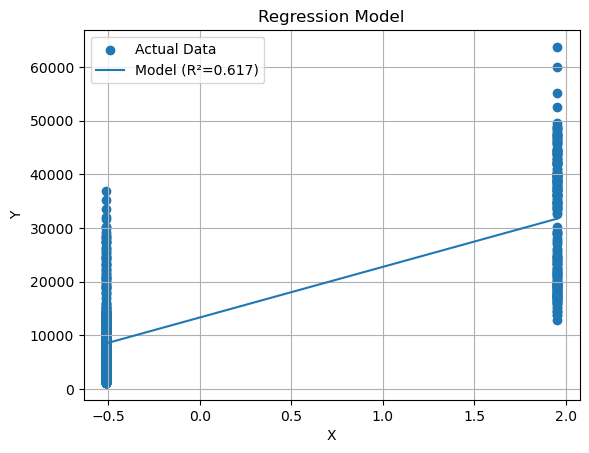

In [48]:
model_s1 = RegressionMLView()
model_s1.fit(X_train_1, y_train)
print("Simple - Top Feature")
model_s1.summary()
print("Test R2:", model_s1.score(X_test_1, y_test))
model_s1.plot(X_train_1, y_train)

In [49]:
model_s2 = RegressionMLView()
model_s2.fit(X_train_2, y_train)
print("Simple - All Features")
model_s2.summary()
print("Test R2:", model_s2.score(X_test_2, y_test))

Simple - All Features
===== Model Summary =====
Intercept (B0): 13325.6342
Weights (W): [3632.16054538  -16.75412312 2003.65147388  571.54047223 9579.56872654
 -147.30116992 -519.28065018 -402.57644678]
R²: 0.7504
Adjusted R²: 0.7485
MSE: 35983973.2398
SSE: 38466867393.3057
L1 (Lasso): 0
L2 (Ridge): 0
Samples (n): 1069
Parameters (p): 9
Test R2: 0.7514824007767145


In [50]:
model_s3 = RegressionMLView()
model_s3.fit(X_train_3, y_train)
print("Simple - Domain Features")
model_s3.summary()
print("Test R2:", model_s3.score(X_test_3, y_test))

Simple - Domain Features
===== Model Summary =====
Intercept (B0): 13325.6340
Weights (W): [3663.45178275 1891.69273196 9558.79621871]
R²: 0.7466
Adjusted R²: 0.7459
MSE: 36521505.9286
SSE: 39041489837.6228
L1 (Lasso): 0
L2 (Ridge): 0
Samples (n): 1069
Parameters (p): 4
Test R2: 0.7493666888458979


Ridge - Top Feature
===== Model Summary =====
Intercept (B0): 13325.6342
Weights (W): [9430.22041592]
R²: 0.6171
Adjusted R²: 0.6167
MSE: 55199286.2130
SSE: 59008036961.7332
L1 (Lasso): 0
L2 (Ridge): 0.1
Samples (n): 1069
Parameters (p): 2
Test R2: 0.6288159684037834


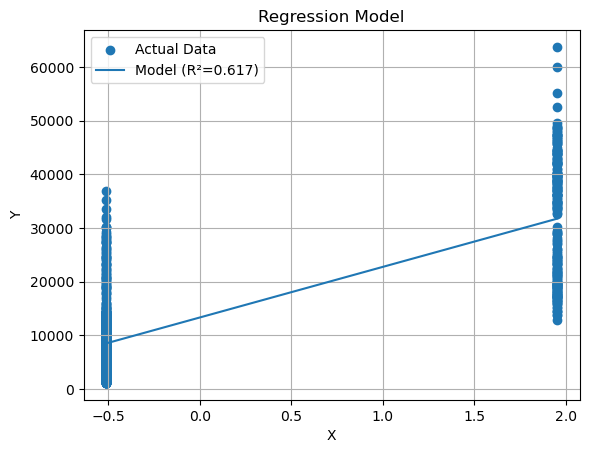

In [57]:
model_r1 = RegressionMLView(l2_lambda=0.1)
model_r1.fit(X_train_1, y_train)
print("Ridge - Top Feature")
model_r1.summary()
print("Test R2:", model_r1.score(X_test_1, y_test))
model_r1.plot(X_train_1, y_train)

In [58]:
model_r2 = RegressionMLView(l2_lambda=0.1)
model_r2.fit(X_train_2, y_train)
print("Ridge - All Features")
model_r2.summary()
print("Test R2:", model_r2.score(X_test_2, y_test))

Ridge - All Features
===== Model Summary =====
Intercept (B0): 13325.6342
Weights (W): [3631.81602737  -16.67476944 2003.45630081  571.50268407 9578.64300546
 -147.21088928 -519.04781494 -402.45290649]
R²: 0.7504
Adjusted R²: 0.7485
MSE: 35983974.6512
SSE: 38466868902.1718
L1 (Lasso): 0
L2 (Ridge): 0.1
Samples (n): 1069
Parameters (p): 9
Test R2: 0.7514774976333675


In [59]:
model_r3 = RegressionMLView(l2_lambda=0.1)
model_r3.fit(X_train_3, y_train)
print("Ridge - Domain Features")
model_r3.summary()
print("Test R2:", model_r3.score(X_test_3, y_test))

Ridge - Domain Features
===== Model Summary =====
Intercept (B0): 13325.6342
Weights (W): [3663.09322177 1891.56070643 9557.88970101]
R²: 0.7466
Adjusted R²: 0.7459
MSE: 36521506.8856
SSE: 39041490860.6582
L1 (Lasso): 0
L2 (Ridge): 0.1
Samples (n): 1069
Parameters (p): 4
Test R2: 0.7493608463283599


Lasso - Top Feature
===== Model Summary =====
Intercept (B0): 13325.6338
Weights (W): [9431.10229076]
R²: 0.6171
Adjusted R²: 0.6167
MSE: 55199285.4348
SSE: 59008036129.8134
L1 (Lasso): 0.1
L2 (Ridge): 0
Samples (n): 1069
Parameters (p): 2
Test R2: 0.6288241085460664


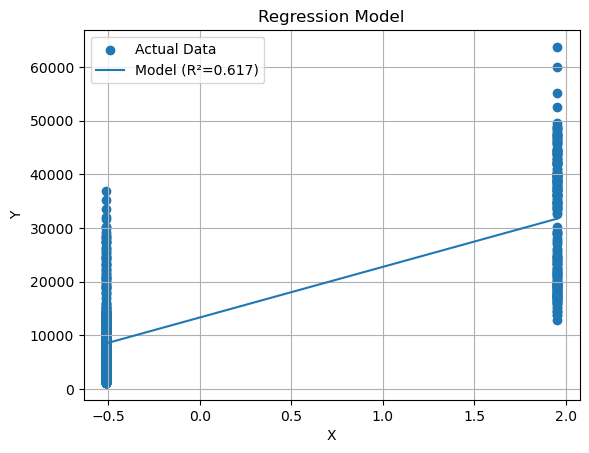

In [60]:
model_l1 = RegressionMLView(l1_lambda=0.1)
model_l1.fit(X_train_1, y_train)
print("Lasso - Top Feature")
model_l1.summary()
print("Test R2:", model_l1.score(X_test_1, y_test))
model_l1.plot(X_train_1, y_train)

In [61]:
model_l2 = RegressionMLView(l1_lambda=0.1)
model_l2.fit(X_train_2, y_train)
print("Lasso - All Features")
model_l2.summary()
print("Test R2:", model_l2.score(X_test_2, y_test))

Lasso - All Features
===== Model Summary =====
Intercept (B0): 13325.6342
Weights (W): [3632.16050619  -16.75407109 2003.65140686  571.54042425 9579.56867055
 -147.30101756 -519.28047707 -402.57628735]
R²: 0.7504
Adjusted R²: 0.7485
MSE: 35983973.2402
SSE: 38466867393.7368
L1 (Lasso): 0.1
L2 (Ridge): 0
Samples (n): 1069
Parameters (p): 9
Test R2: 0.7514824004280054


In [63]:
model_l3 = RegressionMLView(l1_lambda=0.1)
model_l3.fit(X_train_3, y_train)
print("Lasso - Domain Features")
model_l3.summary()
print("Test R2:", model_l3.score(X_test_3, y_test))

Lasso - Domain Features
===== Model Summary =====
Intercept (B0): 13325.6340
Weights (W): [3663.45166637 1891.69275047 9558.79611737]
R²: 0.7466
Adjusted R²: 0.7459
MSE: 36521505.9286
SSE: 39041489837.6230
L1 (Lasso): 0.1
L2 (Ridge): 0
Samples (n): 1069
Parameters (p): 4
Test R2: 0.7493666883433422


### **2nd View: Statistical View**

In [38]:
class StatisticalRegression:
    def __init__(self, lmbda=0, reg_type="ridge"):
        self.beta_0 = None
        self.beta_1 = None
        self.SSE = None
        self.SST = None
        self.MSE = None
        self.sxx = None
        self.sxy = None
        self.r_squared = None
        self.adjusted_r_squared = None
        self.lmbda = lmbda
        self.reg_type = reg_type
        self.n = None
        self.p = 2

    def fit(self, X, y):
        X = np.array(X, dtype=float).flatten()
        y = np.array(y, dtype=float).flatten()
        if len(X) != len(y):
            raise ValueError("X and y must have same length")
        self.n = len(X)
        x_bar = np.mean(X)
        y_bar = np.mean(y)
        self.sxx = np.sum((X - x_bar) ** 2)
        self.sxy = np.sum((X - x_bar) * (y - y_bar))
        self.SST = np.sum((y - y_bar) ** 2)
        if self.sxx == 0:
            raise ValueError("Variance of X is zero")
        if self.reg_type == "lasso":
            self._lasso()
        elif self.reg_type == "ridge":
            self._ridge()
        else:
            raise ValueError("reg_type must be 'lasso' or 'ridge'")
        self.beta_0 = y_bar - self.beta_1 * x_bar
        y_hat = self.predict(X)
        errors = y - y_hat
        self.SSE = np.sum(errors ** 2)
        self.MSE = self.SSE / self.n
        self.r_squared = 1 - (self.SSE / self.SST)
        self.adjusted_r_squared = 1 - (1 - self.r_squared) * (self.n - 1) / (self.n - self.p)

    def _lasso(self):
        threshold = self.lmbda / 2
        if abs(self.sxy) > threshold:
            self.beta_1 = np.sign(self.sxy) * (abs(self.sxy) - threshold) / self.sxx
        else:
            self.beta_1 = 0.0

    def _ridge(self):
        self.beta_1 = self.sxy / (self.sxx + self.lmbda)

    def predict(self, X):
        X = np.array(X, dtype=float).flatten()
        return self.beta_0 + self.beta_1 * X

    def score(self, X, y):
        X = np.array(X, dtype=float).flatten()
        y = np.array(y, dtype=float).flatten()
        y_pred = self.predict(X)
        sse = np.sum((y - y_pred) ** 2)
        sst = np.sum((y - np.mean(y)) ** 2)
        return 1 - (sse / sst)

    def summary(self):
        print("===== Statistical Regression Summary =====")
        print(f"Model type: {self.reg_type}")
        print(f"Intercept (B0): {self.beta_0:.4f}")
        print(f"Slope (B1): {self.beta_1:.4f}")
        print(f"R²: {self.r_squared:.4f}")
        print(f"Adjusted R²: {self.adjusted_r_squared:.4f}")
        print(f"MSE: {self.MSE:.4f}")
        print(f"SSE: {self.SSE:.4f}")
        print(f"Lambda: {self.lmbda}")
        print(f"Samples (n): {self.n}")
        print(f"Parameters (p): {self.p}")

    def plot(self, X, y):
        X = np.array(X).flatten()
        y = np.array(y).flatten()
        y_pred = self.predict(X)
        idx = np.argsort(X)
        X_sorted = X[idx]
        y_sorted = y_pred[idx]
        plt.figure()
        plt.scatter(X, y, label="Actual Data")
        plt.plot(X_sorted, y_sorted, label=f"Model (R²={self.r_squared:.3f})")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title("Statistical Regression")
        plt.legend()
        plt.grid(True)
        plt.show()


=== Statistical Simple ===
===== Statistical Regression Summary =====
Model type: ridge
Intercept (B0): 13325.6342
Slope (B1): 9431.1026
R²: 0.6171
Adjusted R²: 0.6167
MSE: 55199285.4348
SSE: 59008036129.8132
Lambda: 0
Samples (n): 1069
Parameters (p): 2
Test R2: 0.6288241116441382


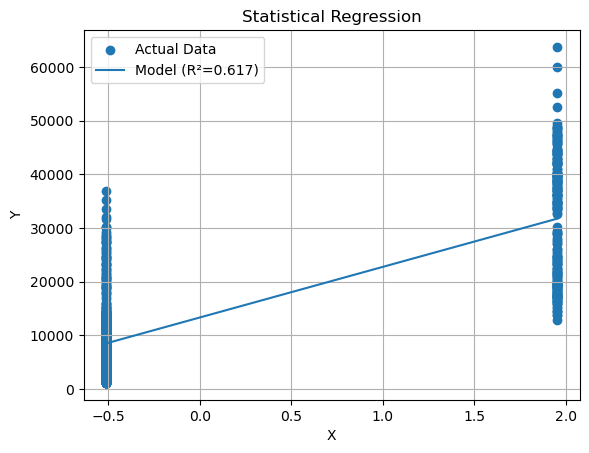

In [ ]:
# Simple Statistical (lambda = 0)
stat_simple = StatisticalRegression(lmbda=0, reg_type="ridge")

stat_simple.fit(X_train_4, y_train)

stat_simple.summary()

y_pred = stat_simple.predict(X_test_4)

r2 = stat_simple.score(X_test_4, y_test)
print("Test R2:", r2)

stat_simple.plot(X_train_4, y_train)

===== Statistical Regression Summary =====
Model type: ridge
Intercept (B0): 13325.6342
Slope (B1): 9422.2885
R²: 0.6171
Adjusted R²: 0.6167
MSE: 55199363.1234
SSE: 59008119178.9433
Lambda: 1.0
Samples (n): 1069
Parameters (p): 2
Test R2: 0.6287423232901771


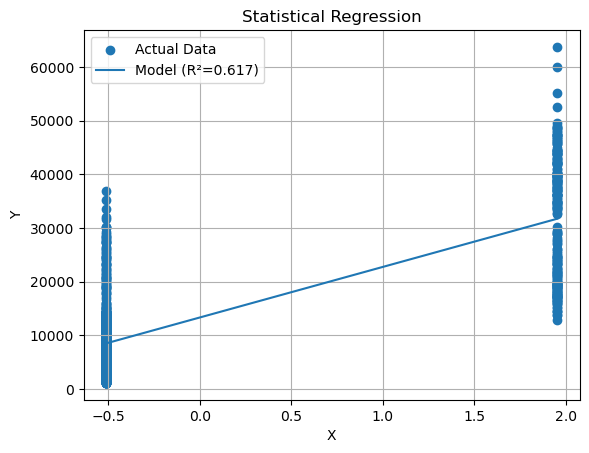

In [42]:
# Statistical Ridge
stat_ridge = StatisticalRegression(lmbda=1.0, reg_type="ridge")

stat_ridge.fit(X_train_4, y_train)

stat_ridge.summary()

y_pred = stat_ridge.predict(X_test_4)

r2 = stat_ridge.score(X_test_4, y_test)
print("Test R2:", r2)

stat_ridge.plot(X_train_4, y_train)

===== Statistical Regression Summary =====
Model type: lasso
Intercept (B0): 13325.6342
Slope (B1): 9431.1024
R²: 0.6171
Adjusted R²: 0.6167
MSE: 55199285.4348
SSE: 59008036129.8133
Lambda: 0.5
Samples (n): 1069
Parameters (p): 2
Test R2: 0.6288241094866256


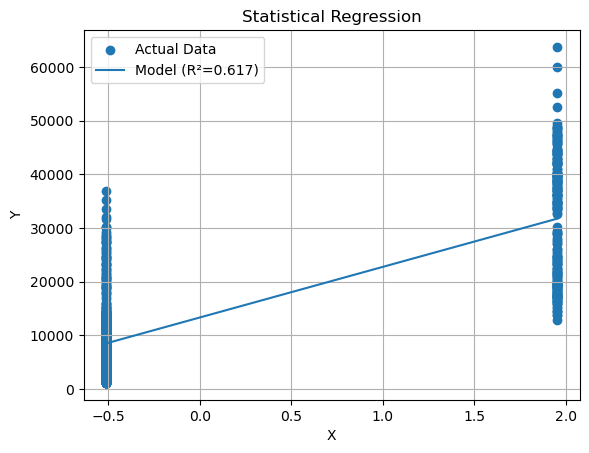

In [43]:
# Statistical Lasso
stat_lasso = StatisticalRegression(lmbda=0.5, reg_type="lasso")

stat_lasso.fit(X_train_4, y_train)

stat_lasso.summary()

y_pred = stat_lasso.predict(X_test_4)

r2 = stat_lasso.score(X_test_4, y_test)
print("Test R2:", r2)

stat_lasso.plot(X_train_4, y_train)

### **3rd View: Numerical View**

In [40]:
class NumericalRegression:
    def __init__(self, l1=0, l2=0):
        self.beta_0 = None
        self.beta_1 = None
        self.SSE = None
        self.SST = None
        self.MSE = None
        self.r_squared = None
        self.adjusted_r_squared = None
        self.loss_history = []
        self.l1 = l1
        self.l2 = l2
        self.n = None
        self.p = 2

    def fit(self, X, y, lr=0.01, epochs=1000, tolerance=1e-6):
        X = np.array(X, dtype=float).flatten()
        y = np.array(y, dtype=float).flatten()
        if len(X) != len(y):
            raise ValueError("X and y must have same length")
        self.n = len(X)
        self.beta_0 = 0.0
        self.beta_1 = 0.0
        prev_sse = float('inf')
        self.loss_history = []
        for _ in range(epochs):
            y_pred = self.predict(X)
            error = y_pred - y
            db0 = (2 / self.n) * np.sum(error)
            db1 = (2 / self.n) * np.sum(X * error)
            db1 += self._lasso_grad() + self._ridge_grad()
            self.beta_0 -= lr * db0
            self.beta_1 -= lr * db1
            current_sse = np.sum((y - self.predict(X)) ** 2)
            self.loss_history.append(current_sse / self.n)
            if abs(prev_sse - current_sse) < tolerance:
                break
            prev_sse = current_sse
        self.SSE = current_sse
        self.MSE = self.SSE / self.n
        self.SST = np.sum((y - np.mean(y)) ** 2)
        self.r_squared = 1 - (self.SSE / self.SST)
        self.adjusted_r_squared = 1 - (1 - self.r_squared) * (self.n - 1) / (self.n - self.p)

    def _lasso_grad(self):
        return (self.l1 / self.n) * np.sign(self.beta_1)

    def _ridge_grad(self):
        return (2 * self.l2 / self.n) * self.beta_1

    def predict(self, X):
        X = np.array(X, dtype=float).flatten()
        return self.beta_0 + self.beta_1 * X

    def score(self, X, y):
        X = np.array(X, dtype=float).flatten()
        y = np.array(y, dtype=float).flatten()

        y_pred = self.predict(X)

        sse = np.sum((y - y_pred) ** 2)
        sst = np.sum((y - np.mean(y)) ** 2)

        return 1 - (sse / sst)

    def summary(self):
        print("===== Numerical Regression Summary =====")
        print(f"Intercept (B0): {self.beta_0:.4f}")
        print(f"Slope (B1): {self.beta_1:.4f}")
        print(f"R²: {self.r_squared:.4f}")
        print(f"Adjusted R²: {self.adjusted_r_squared:.4f}")
        print(f"MSE: {self.MSE:.4f}")
        print(f"SSE: {self.SSE:.4f}")
        print(f"L1 (Lasso): {self.l1}")
        print(f"L2 (Ridge): {self.l2}")
        print(f"Samples (n): {self.n}")
        print(f"Parameters (p): {self.p}")

    def plot(self, X, y):
        X = np.array(X).flatten()
        y = np.array(y).flatten()
        y_pred = self.predict(X)
        idx = np.argsort(X)
        X_sorted = X[idx]
        y_sorted = y_pred[idx]
        plt.figure()
        plt.scatter(X, y, label="Actual Data")
        plt.plot(X_sorted, y_sorted, label=f"Model (R²={self.r_squared:.3f})")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title("Numerical Regression")
        plt.legend()
        plt.grid(True)
        plt.show()

===== Numerical Regression Summary =====
Intercept (B0): 13325.6338
Slope (B1): 9431.1023
R²: 0.6171
Adjusted R²: 0.6167
MSE: 55199285.4348
SSE: 59008036129.8135
L1 (Lasso): 0
L2 (Ridge): 0
Samples (n): 1069
Parameters (p): 2
Test R2: 0.6288241083805741


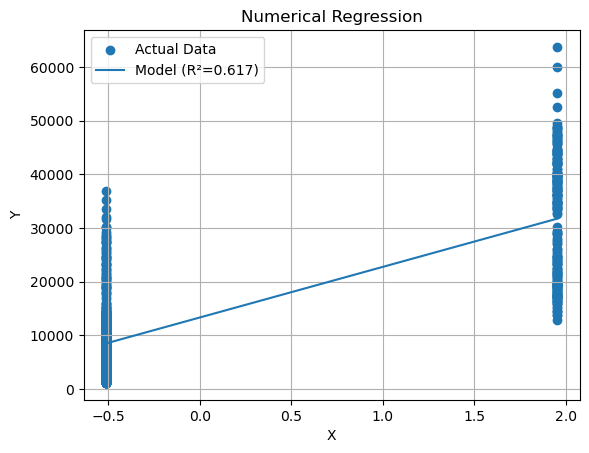

In [45]:
# Numerical Simple (no regularization)
num_simple = NumericalRegression(l1=0, l2=0)

num_simple.fit(X_train_4, y_train)

num_simple.summary()

y_pred = num_simple.predict(X_test_4)

r2 = num_simple.score(X_test_4, y_test)
print("Test R2:", r2)

num_simple.plot(X_train_4, y_train)

===== Numerical Regression Summary =====
Intercept (B0): 13325.6342
Slope (B1): 9422.2885
R²: 0.6171
Adjusted R²: 0.6167
MSE: 55199363.1237
SSE: 59008119179.2364
L1 (Lasso): 0
L2 (Ridge): 1.0
Samples (n): 1069
Parameters (p): 2
Test R2: 0.6287423231206108


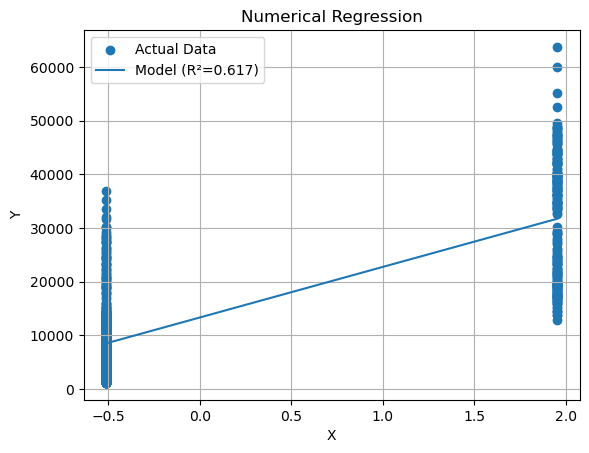

In [46]:
# Numerical Ridge
num_ridge = NumericalRegression(l1=0, l2=1.0)

num_ridge.fit(X_train_4, y_train)

num_ridge.summary()

y_pred = num_ridge.predict(X_test_4)

r2 = num_ridge.score(X_test_4, y_test)
print("Test R2:", r2)

num_ridge.plot(X_train_4, y_train)

===== Numerical Regression Summary =====
Intercept (B0): 13325.6339
Slope (B1): 9431.1021
R²: 0.6171
Adjusted R²: 0.6167
MSE: 55199285.4348
SSE: 59008036129.8135
L1 (Lasso): 0.5
L2 (Ridge): 0
Samples (n): 1069
Parameters (p): 2
Test R2: 0.6288241073078442


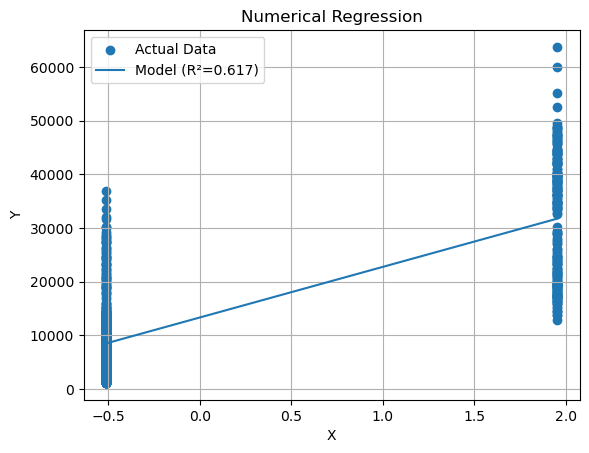

In [47]:
# Numerical Lasso
num_lasso = NumericalRegression(l1=0.5, l2=0)

num_lasso.fit(X_train_4, y_train)

num_lasso.summary()

y_pred = num_lasso.predict(X_test_4)

r2 = num_lasso.score(X_test_4, y_test)
print("Test R2:", r2)

num_lasso.plot(X_train_4, y_train)

#### Another try in SImple Regression with another feauter "Age by statistical view"

In [64]:
# Prepare training and testing data using only the selected top feature (Stat and Num)
X_train_5 = df_train["age"].values 
X_test_5 = df_test["age"].values

===== Statistical Regression Summary =====
Model type: ridge
Intercept (B0): 13325.6342
Slope (B1): 3554.7912
R²: 0.0877
Adjusted R²: 0.0868
MSE: 131508441.1438
SSE: 140582523582.6978
Lambda: 0
Samples (n): 1069
Parameters (p): 2
Test R2: 0.09356425528007839


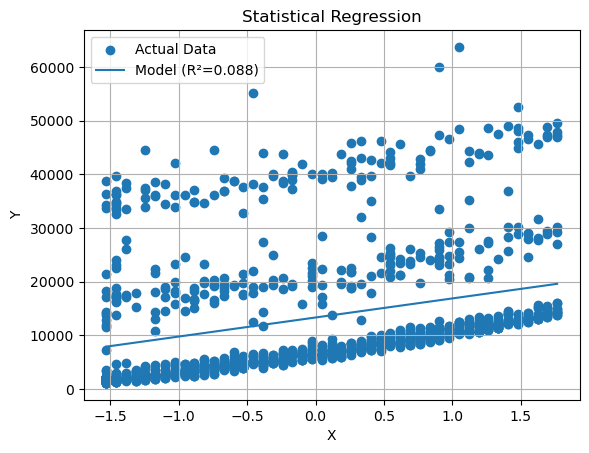

In [65]:
# Simple Statistical (lambda = 0)
stat_simple = StatisticalRegression(lmbda=0, reg_type="ridge")

stat_simple.fit(X_train_5, y_train)

stat_simple.summary()

y_pred = stat_simple.predict(X_test_5)

r2 = stat_simple.score(X_test_5, y_test)
print("Test R2:", r2)

stat_simple.plot(X_train_5, y_train)

## **Visualization**

In [66]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### **1. Correlation Heatmap**

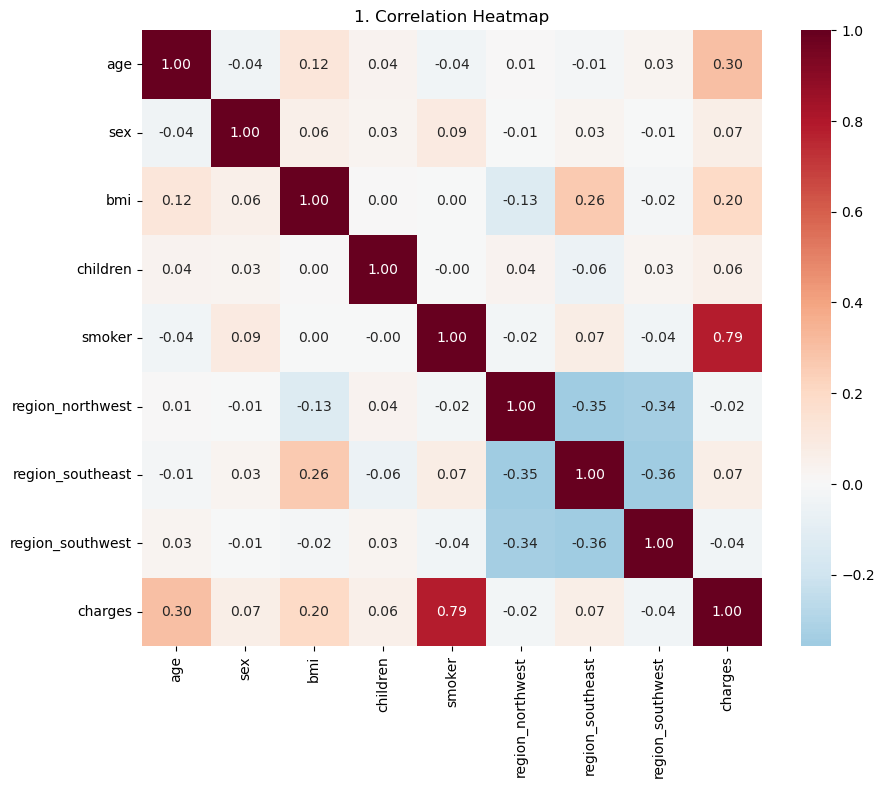

In [87]:
# Convert X_train to DataFrame if it's a numpy array to keep feature names
X_train_df = pd.DataFrame(X_train, columns=feature_names) if isinstance(X_train, np.ndarray) else X_train

# Combine features with target for correlation calculation
train_data_for_corr = X_train_df.copy()
train_data_for_corr['charges'] = y_train

# Plotting using Seaborn for a professional static look
plt.figure(figsize=(10, 8))
sns.heatmap(train_data_for_corr.corr(), annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("1. Correlation Heatmap")
plt.show()

### **2. interactive scatter plot with a dropdown menu for feature selection**

In [ ]:
fig2 = go.Figure()

for col in feature_names:
    # Add scatter points for the current feature
    fig2.add_trace(go.Scatter(x=X_train_df[col], y=Y_train, mode='markers', 
                             name=f'Data: {col}', visible=False, opacity=0.4))
    m, b = np.polyfit(X_train_df[col], Y_train, 1)
    x_range = np.linspace(X_train_df[col].min(), X_train_df[col].max(), 100)
    fig2.add_trace(go.Scatter(x=x_range, y=m*x_range + b, mode='lines', 
                             name=f'Fit Line', visible=False, line=dict(color='red', width=3)))
    
fig2.data[0].visible = True
fig2.data[1].visible = True

buttons = [dict(label=col, method="update", 
           args=[{"visible": [i==idx*2 or i==idx*2+1 for i in range(len(fig2.data))]}, 
           {"title": f"Scatter: {col} vs Charges"}]) for idx, col in enumerate(feature_names)]

fig2.update_layout(updatemenus=[dict(active=0, buttons=buttons, x=1.1, y=1.1)], 
                  title="2. Interactive Scatter Plot: User-selectable X vs Y")
fig2.show()

### **3. Gradient Descent Convergence Plot**

In [88]:
fig3 = go.Figure()

fig3.add_trace(go.Scatter(y=num_simple.loss_history, mode='lines', name='Linear'))
fig3.add_trace(go.Scatter(y=num_lasso.loss_history, mode='lines', name='Lasso'))
fig3.add_trace(go.Scatter(y=num_ridge.loss_history, mode='lines', name='Ridge'))

fig3.update_layout(
    title="3. Gradient Descent Convergence",
    xaxis_title="Iterations",
    yaxis_title="Loss",
    yaxis_type="log"
)

fig3.show()

### **4. Residual Plots for Model Specifications**

In [89]:
models = [num_simple, num_lasso, num_ridge]
names = ["Linear", "Lasso", "Ridge"]

fig4 = go.Figure()

for model, name in zip(models, names):
    preds = model.predict(X_test_4).flatten()
    residuals = y_test - preds

    fig4.add_trace(go.Scatter(
        x=preds,
        y=residuals,
        mode='markers',
        name=name,
        opacity=0.6
    ))

fig4.add_hline(y=0, line_dash="dash")

fig4.update_layout(
    title="4. Residual Plot (All Models)",
    xaxis_title="Predicted",
    yaxis_title="Residuals"
)

fig4.show()

### **5. Coefficient Bar Chart**

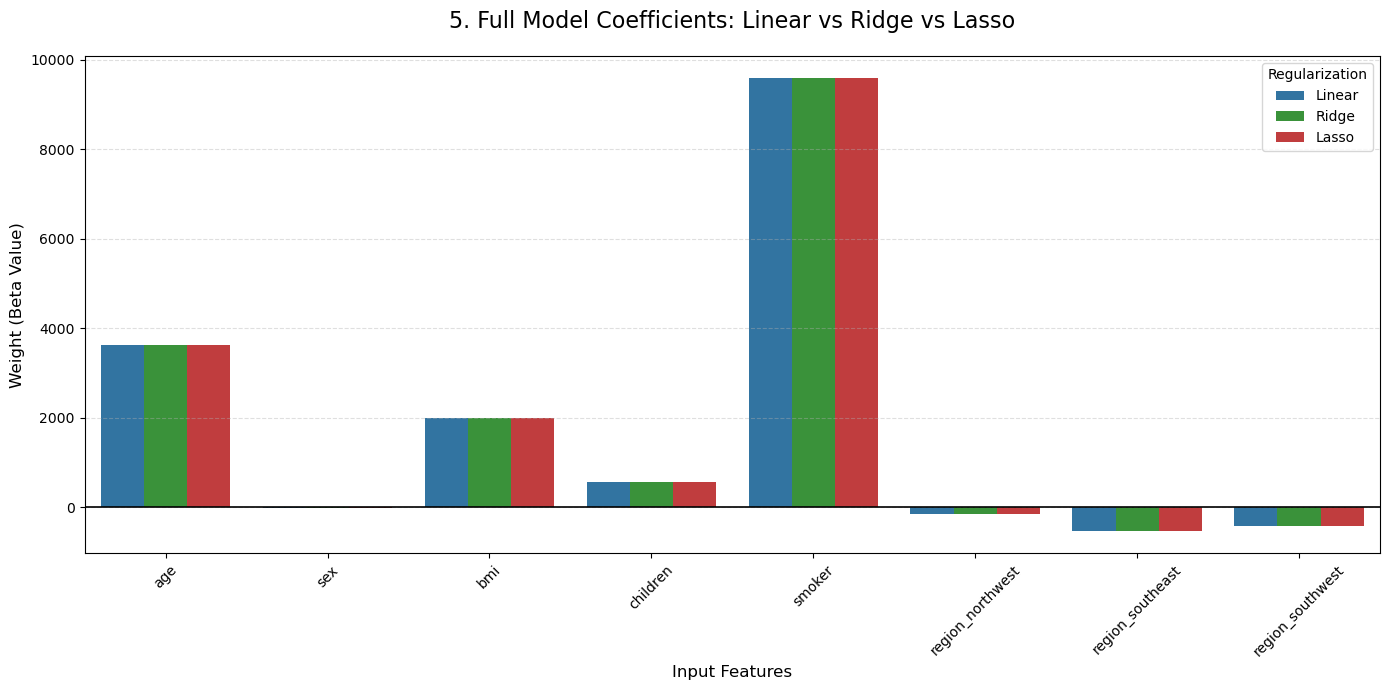

In [93]:
full_features = all_features 

plot_data = []

specs = {
    "Linear": model_s2,
    "Ridge":  model_r2,
    "Lasso":  model_l2
}

for name, model in specs.items():
    weights = model.W.flatten()
    for feature, weight in zip(full_features, weights):
        plot_data.append({
            "Model": name,
            "Feature": feature,
            "Weight": weight
        })

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_plot, x="Feature", y="Weight", hue="Model", palette=['#1f77b4', '#2ca02c', '#d62728'])

plt.axhline(0, color='black', linewidth=1.2)
plt.title("5. Full Model Coefficients: Linear vs Ridge vs Lasso", fontsize=16, pad=20)
plt.ylabel("Weight (Beta Value)", fontsize=12)
plt.xlabel("Input Features", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Regularization")

plt.tight_layout()
plt.show()